# Residual study

`scp fermi:kerr/toby_files/toby_v3.* files/kerr

In [1]:
%reset -f
%run pylib/tools dark date
from pylib import pixel_table as pt_mod; reload(pt_mod)
PixelTable = pt_mod.PixelTable
from pylib.pixel_table import *
pixel_table = pt = PixelTable('files/kerr/toby_v4.fits')

<h5 style="text-align:right; margin-right:15px"> 2026-04-06 07:23</h5>

Loaded pixel table from "files/kerr/toby_v4.fits":
            42 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            


## plot residuals for 1.33 GeV 

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7ada487d1f90>
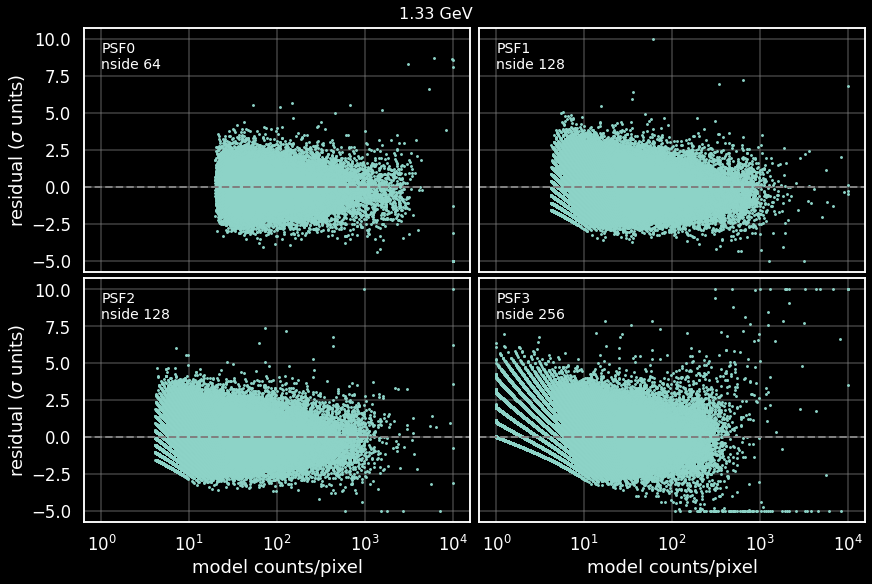

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7ada4840e6e0>
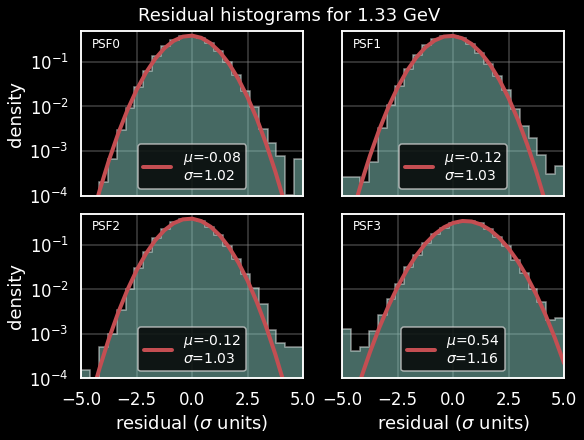

In [2]:
show(f'## plot residuals for {pt[0,(energy_index:=4)].energy} ')
show_fig(plot_residuals_for_given_energy,pt, energy_index)   
show_fig(histograms_of_residuals_for_given_energy,pt, energy_index)

In [3]:
self = ResidualPoints(pixel_table, energy_index=energy_index)

show(self.df.describe())

,pixel,data,model,sigma,glon,glat,psf,nside
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000
mean,318337.590674,1481.015544,1279.381655,6.878304,-14.622831,3.566939,2.647668,228.808290
std,227771.687592,4611.687461,4186.933665,4.001775,105.128242,35.080191,0.835543,59.358459
min,3967.000000,6.000000,0.912907,5.000771,-178.636364,-70.535950,0.000000,64.000000
25%,93963.000000,10.000000,1.924460,5.191649,-116.718750,-22.993394,3.000000,256.000000
50%,301118.000000,55.000000,25.733438,5.580551,-28.229814,3.433834,3.000000,256.000000
75%,496773.000000,571.000000,459.618958,6.942299,78.694581,28.971532,3.000000,256.000000
max,764128.000000,39815.000000,38595.945312,38.631587,180.000000,72.017625,3.000000,256.000000


In [4]:
# reload(kerr_funcs); from pylib.kerr_funcs import ResidualPoints
self = ResidualPoints(pixel_table, energy_index=energy_index)

show(self.df.describe())

,pixel,data,model,sigma,glon,glat,psf,nside
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000
mean,318337.590674,1481.015544,1279.381655,6.878304,-14.622831,3.566939,2.647668,228.808290
std,227771.687592,4611.687461,4186.933665,4.001775,105.128242,35.080191,0.835543,59.358459
min,3967.000000,6.000000,0.912907,5.000771,-178.636364,-70.535950,0.000000,64.000000
25%,93963.000000,10.000000,1.924460,5.191649,-116.718750,-22.993394,3.000000,256.000000
50%,301118.000000,55.000000,25.733438,5.580551,-28.229814,3.433834,3.000000,256.000000
75%,496773.000000,571.000000,459.618958,6.942299,78.694581,28.971532,3.000000,256.000000
max,764128.000000,39815.000000,38595.945312,38.631587,180.000000,72.017625,3.000000,256.000000


In [5]:
self.clusterer()
self.cldf

,glon,glat,data,model,sigma,n,ids
0,9.141,28.631,813,669.7,5.5,2,"[1, 2]"
1,113.906,-4.182,6894,6205.6,8.7,2,"[5, 6]"
2,-152.191,57.019,208,127.3,7.2,2,"[12, 21]"
3,-158.906,28.972,556,428.6,6.2,2,"[14, 26]"
4,-161.016,28.972,1323,988.1,10.7,3,"[15, 28, 27]"
5,58.008,-4.182,17908,16389.9,11.9,2,"[16, 29]"
6,-78.047,-39.065,136,72.8,7.4,2,"[32, 33]"
7,-125.140,57.019,105,59.6,5.9,4,"[35, 38, 37, 36]"
8,32.344,30.172,240,163.0,6.0,2,"[41, 43]"
9,178.816,69.051,100,59.3,5.3,2,"[69, 70]"


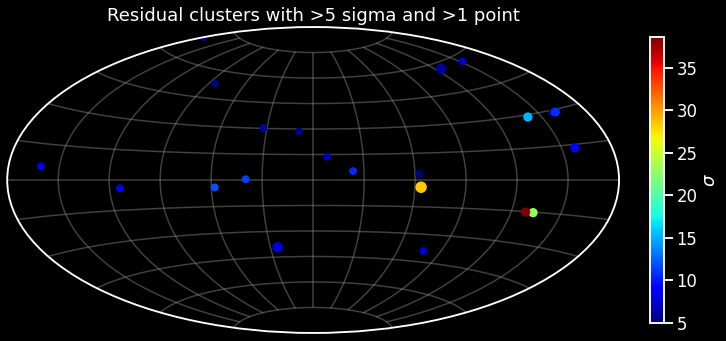

In [6]:
self.ait_cluster_plot()

In [7]:
from utilities.catalogs import UWcat, Fermi4FGL
show(f""" ## Compare with {(fglname:='uw1617')}""")
fgl = Fermi4FGL(fglname)
# for test in ResidualPoints(pixel_table(1,4)).points:
#     t  = fgl.catalog_entry(test, 1)
#     if t is not None:
#         print(t.name, round(t.ts),  round(t.sep,1))

## Compare with uw1617

Loaded Fermi 4FGL gll_pscP305uw1617_v4_assoc_v9r1_classes.fits: 7221 entries


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7ada4609ca30>
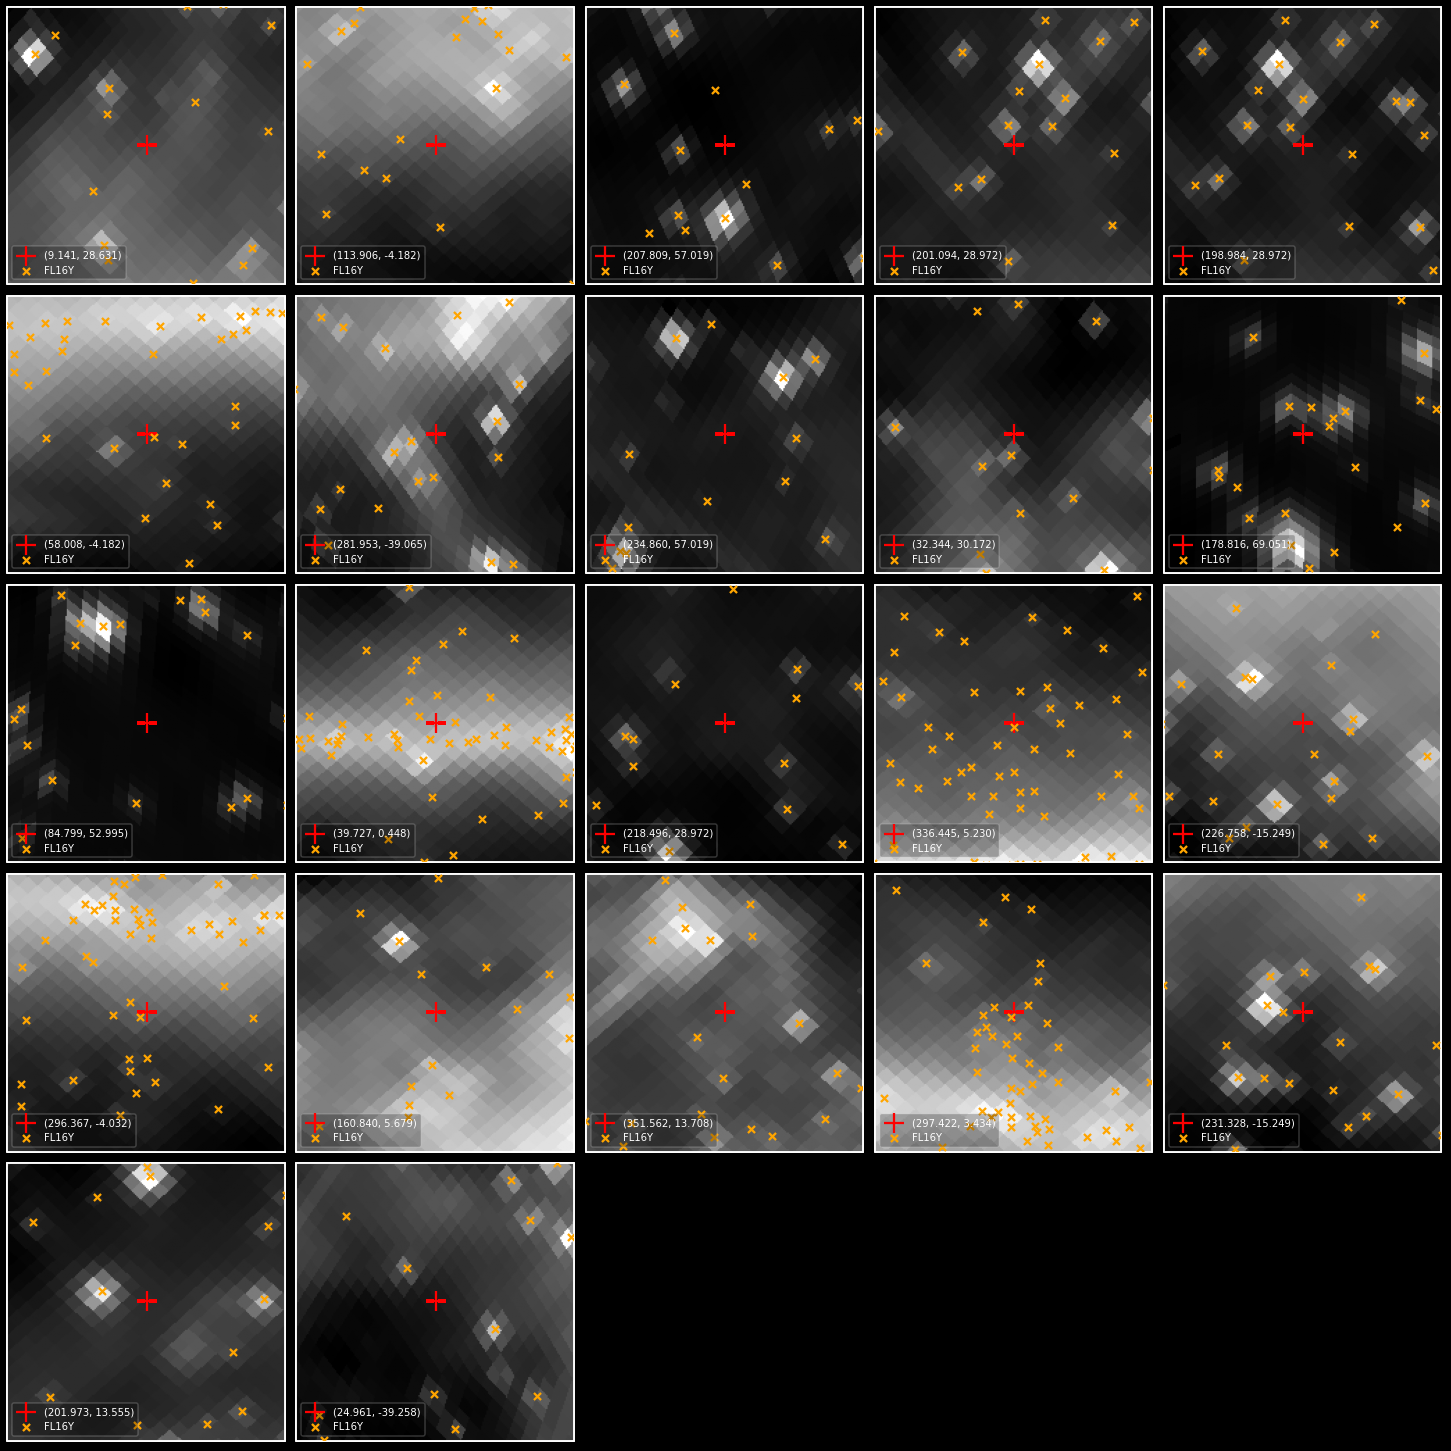

In [8]:
def residual_scatter(center, band,  fgl,*, component='model', fig=None, figsize=(8,8),**kwargs):
    
    (band.zea_plot(center=center, component=component, size=10, cmap='gist_gray',title='',
        fig=fig,figsize=figsize,  axes_visible=False, **kwargs)  
        .scatter(center,marker='+',color='red',s=400, 
                label=f'({center.l.deg:.3f}, {center.b.deg:.3f})')
        .scatter(fgl, marker='x',s=50, color='orange', label='FL16Y')
        .legend(loc='lower left',fontsize=10, framealpha=0.25)
    )
    if fig is not None: plt.gca().set(xlabel='',ylabel='', yticklabels=[], xticklabels=[])
    if fig is None: plt.show()


band = pixel_table(2,energy_index)
fig = plt.figure(figsize=(20,20))
subfigs = fig.subfigures(5,5)
for point, sfig in zip(self.clpoints, subfigs.flat):
    residual_scatter(point, band,  fgl, fig=sfig, colorbar=False, )
show(fig)

### Residual check plots for model<100 

,glon,glat,data,model,sigma,n,ids
6,-78.047,-39.065,136,72.8,7.4,2,"[32, 33]"
7,-125.140,57.019,105,59.6,5.9,4,"[35, 38, 37, 36]"
9,178.816,69.051,100,59.3,5.3,2,"[69, 70]"
10,84.799,52.995,13,3.5,5.0,2,"[81, 82]"
21,24.961,-39.258,78,33.8,7.6,4,"[151, 152, 153, 154]"


<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7ada44d12170>
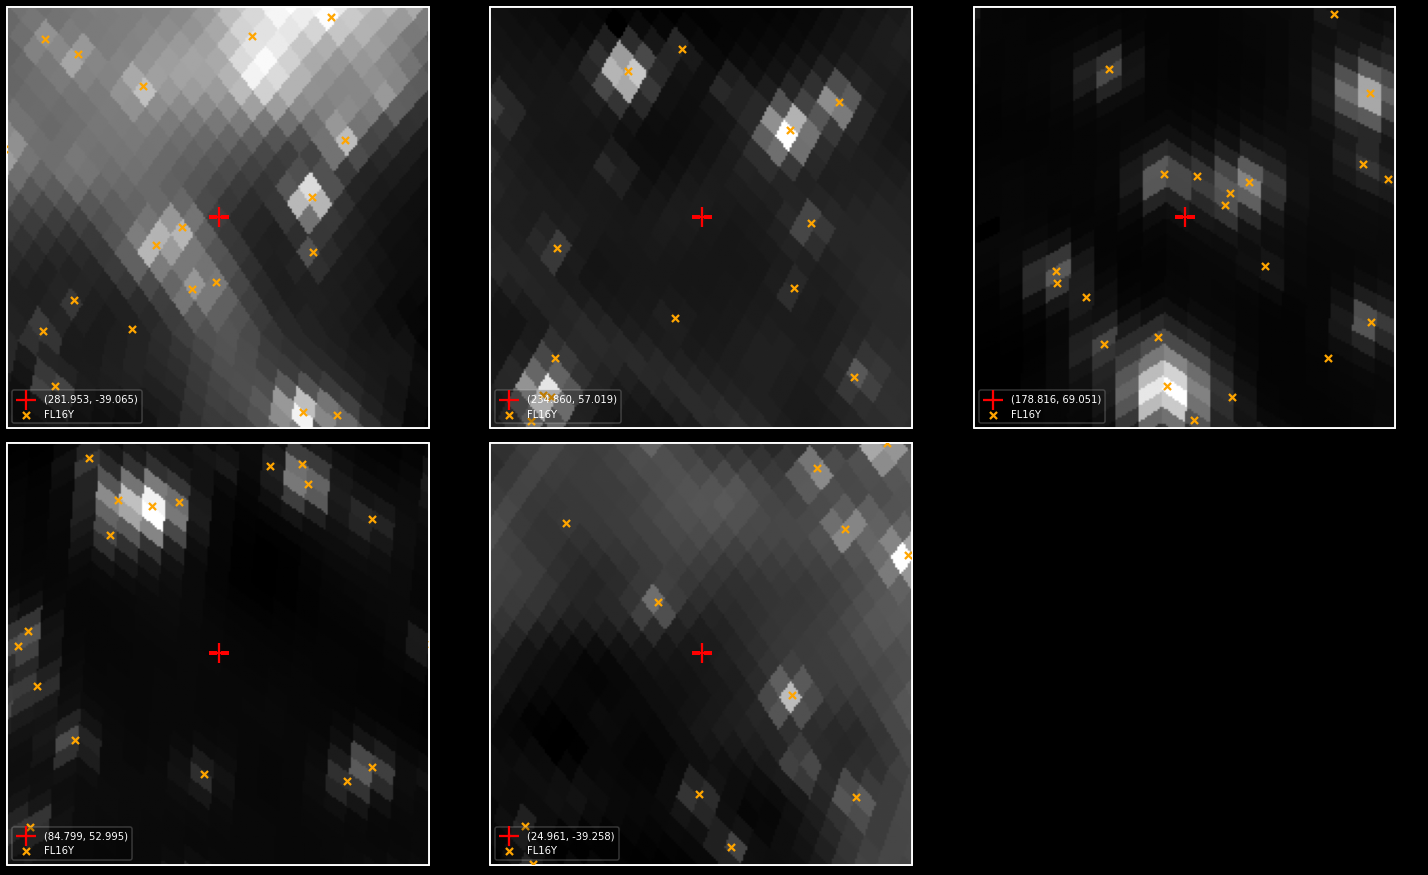

In [9]:
show(f"""### Residual check plots for model<100 """)
fig = plt.figure(figsize=(20,12))
subfigs = fig.subfigures(2,3)

df = self.cldf.query('model<100'); show(df)
for point, sfig in zip(SkyCoord(df.glon, df.glat, unit='deg',frame='galactic'), subfigs.flat):
    residual_scatter(point, band, fgl, component='model', fig=sfig, colorbar=False, )
show(fig)

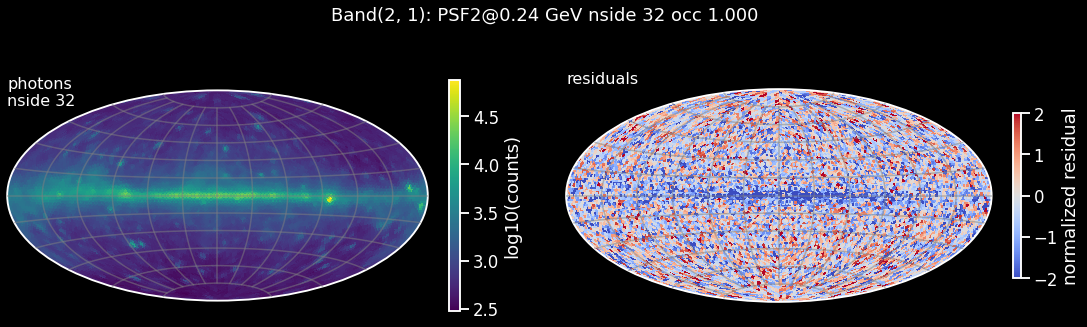

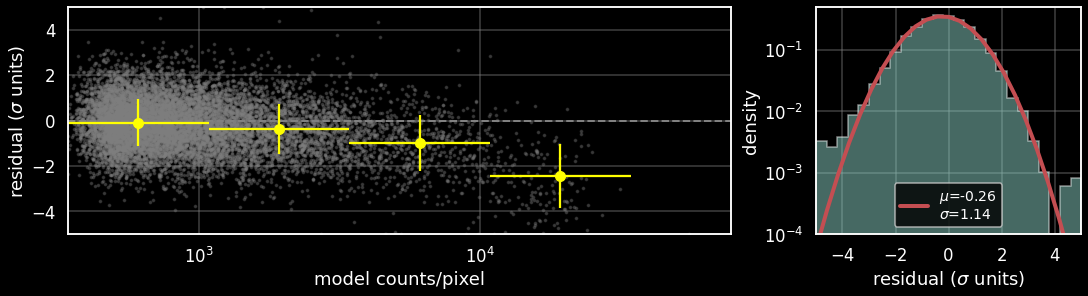

In [10]:
ResidualPlotter(pixel_table(2,1)).plots()

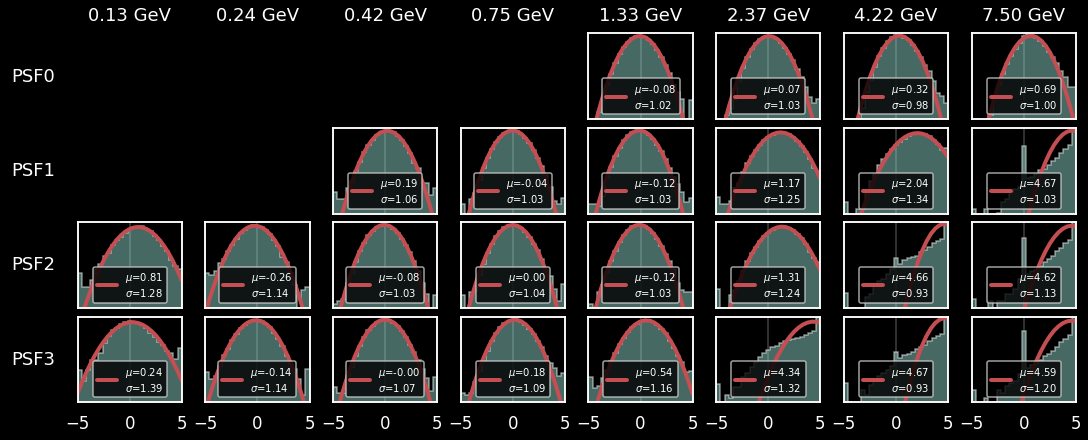

In [11]:
# assert False
multi_residual_plotter(pixel_table, nside=64)
# for i in range(0,6):
#     ResidualPlotter(pixel_table(2,i), 64).plots()
# for i in range(0,6):
#     ResidualPlotter(pixel_table(3,i)).plots()

In [12]:
from scipy.stats import norm

cluster_rows = []
for cluster_id, row in self.cldf.iterrows():
    point = SkyCoord(row.glon, row.glat, unit='deg', frame='galactic')
    near = fgl.select_cone(point, cone_size=1.0).sort_values('sep')
    best = near.iloc[0] if len(near) else None
    cluster_rows.append(dict(
        cluster=int(cluster_id),
        glon=row.glon,
        glat=row.glat,
        sigma=row.sigma,
        npts=int(row.n),
        model=row.model,
        photons=int(row.data),
        nearest_4fgl=None if best is None else best.name,
        sep_deg=np.nan if best is None else round(float(best.sep), 3),
        matched_0p5deg=bool(best is not None and float(best.sep) <= 0.5),
    ))

cluster_match_df = pd.DataFrame(cluster_rows).sort_values(
    ['matched_0p5deg', 'sigma', 'npts'], ascending=[True, False, False]
).reset_index(drop=True)

show('## Residual clusters cross-matched to 4FGL within 1 deg')
show(cluster_match_df)

unmatched_df = cluster_match_df.query('matched_0p5deg == False')
show(f'### Unmatched within 0.5 deg: {len(unmatched_df)} of {len(cluster_match_df)} clusters')
show(unmatched_df[['cluster', 'glon', 'glat', 'sigma', 'npts', 'model', 'nearest_4fgl', 'sep_deg']])

## Residual clusters cross-matched to 4FGL within 1 deg

,cluster,glon,glat,sigma,npts,model,photons,nearest_4fgl,sep_deg,matched_0p5deg
0,19,-128.672,-15.249,38.6,3,17883.8,23050,FL16Y02889,0.728,False
1,14,-133.242,-15.249,22.9,3,11977.6,14482,None,NaN,False
2,12,-141.504,28.972,15.2,3,479.9,812,None,NaN,False
3,11,39.727,0.448,11.4,2,2007.6,2520,FL16Y09794,0.593,False
4,4,-161.016,28.972,10.7,3,988.1,1323,FL16Y03643,0.801,False
5,20,-158.027,13.555,9.1,3,2148.7,2569,None,NaN,False
6,1,113.906,-4.182,8.7,2,6205.6,6894,None,NaN,False
7,16,160.840,5.679,8.1,2,677.0,888,None,NaN,False
8,21,24.961,-39.258,7.6,4,33.8,78,None,NaN,False
9,6,-78.047,-39.065,7.4,2,72.8,136,FL16Y01679,0.916,False


### Unmatched within 0.5 deg: 18 of 22 clusters

,cluster,glon,glat,sigma,npts,model,nearest_4fgl,sep_deg
0,19,-128.672,-15.249,38.6,3,17883.8,FL16Y02889,0.728
1,14,-133.242,-15.249,22.9,3,11977.6,None,NaN
2,12,-141.504,28.972,15.2,3,479.9,None,NaN
3,11,39.727,0.448,11.4,2,2007.6,FL16Y09794,0.593
4,4,-161.016,28.972,10.7,3,988.1,FL16Y03643,0.801
5,20,-158.027,13.555,9.1,3,2148.7,None,NaN
6,1,113.906,-4.182,8.7,2,6205.6,None,NaN
7,16,160.840,5.679,8.1,2,677.0,None,NaN
8,21,24.961,-39.258,7.6,4,33.8,None,NaN
9,6,-78.047,-39.065,7.4,2,72.8,FL16Y01679,0.916


In [14]:
bias_rows = []
for key, band_i in pixel_table.items():
    rp = ResidualPlotter(band_i, nside=64)
    good = rp.rnorm[~np.isnan(rp.rnorm)]
    mu, sigma = norm.fit(good)
    bias_rows.append(dict(
        psf=band_i.psf_name.upper(),
        energy_index=int(key[1]),
        energy=band_i.energy,
        mu=round(float(mu), 2),
        width=round(float(sigma), 2),
        npix=len(good),
    ))

bias_df = pd.DataFrame(bias_rows).sort_values(['energy_index', 'psf']).reset_index(drop=True)
high_energy_bias_df = bias_df.query('energy_index >= 5').copy()
high_energy_bias_df['abs_mu'] = high_energy_bias_df.mu.abs()

show('## High-energy residual bias summary (energy index >= 5)')
show(high_energy_bias_df.sort_values(['energy_index', 'psf']))

show('### Most biased high-energy bands by |mu|')
show(high_energy_bias_df.sort_values(['abs_mu', 'width'], ascending=[False, False])[['psf', 'energy', 'mu', 'width', 'npix']].head(8))

## High-energy residual bias summary (energy index >= 5)

,psf,energy_index,energy,mu,width,npix,abs_mu
14,PSF0,5,2.37 GeV,0.07,1.03,49152,0.07
15,PSF1,5,2.37 GeV,1.17,1.25,49152,1.17
16,PSF2,5,2.37 GeV,1.31,1.24,49152,1.31
17,PSF3,5,2.37 GeV,4.34,1.32,49152,4.34
18,PSF0,6,4.22 GeV,0.32,0.98,49152,0.32
19,PSF1,6,4.22 GeV,2.04,1.34,49152,2.04
20,PSF2,6,4.22 GeV,4.66,0.93,49152,4.66
21,PSF3,6,4.22 GeV,4.67,0.93,49152,4.67
22,PSF0,7,7.50 GeV,0.69,1.00,49152,0.69
23,PSF1,7,7.50 GeV,4.67,1.03,49152,4.67


### Most biased high-energy bands by |mu|

,psf,energy,mu,width,npix
23,PSF1,7.50 GeV,4.67,1.03,49152
21,PSF3,4.22 GeV,4.67,0.93,49152
20,PSF2,4.22 GeV,4.66,0.93,49152
24,PSF2,7.50 GeV,4.62,1.13,49152
25,PSF3,7.50 GeV,4.59,1.20,49152
17,PSF3,2.37 GeV,4.34,1.32,49152
27,PSF1,13.34 GeV,4.11,1.83,49152
28,PSF2,13.34 GeV,4.08,1.93,49152


In [15]:
show('### Notebook-plotted high-energy bins (2.37, 4.22, 7.50 GeV)')
show(high_energy_bias_df.query('energy_index <= 7')[['psf', 'energy_index', 'energy', 'mu', 'width', 'npix']])

### Notebook-plotted high-energy bins (2.37, 4.22, 7.50 GeV)

,psf,energy_index,energy,mu,width,npix
14,PSF0,5,2.37 GeV,0.07,1.03,49152
15,PSF1,5,2.37 GeV,1.17,1.25,49152
16,PSF2,5,2.37 GeV,1.31,1.24,49152
17,PSF3,5,2.37 GeV,4.34,1.32,49152
18,PSF0,6,4.22 GeV,0.32,0.98,49152
19,PSF1,6,4.22 GeV,2.04,1.34,49152
20,PSF2,6,4.22 GeV,4.66,0.93,49152
21,PSF3,6,4.22 GeV,4.67,0.93,49152
22,PSF0,7,7.50 GeV,0.69,1.00,49152
23,PSF1,7,7.50 GeV,4.67,1.03,49152


In [ ]:
export_path = 'files/residual_cluster_matches_uw1617.csv'
cluster_match_df.to_csv(export_path, index=False)
show(f'## Wrote cluster cross-match table to {export_path}')
show(cluster_match_df[['cluster', 'glon', 'glat', 'sigma', 'npts', 'model', 'nearest_4fgl', 'sep_deg', 'matched_0p5deg']])

## Wrote cluster cross-match table to files/residual_cluster_matches_uw1617.csv

,cluster,glon,glat,sigma,npts,model,nearest_4fgl,sep_deg,matched_0p5deg
0,22,-162.773,-17.739,5.7,2,2.7,None,NaN,False
1,5,-71.250,-63.448,5.5,2,52.8,FL16Y00648,0.514,False
2,8,49.821,64.199,5.2,2,1.9,FL16Y06566,0.509,False
3,2,-164.883,4.182,11.9,12,16389.9,PSRJ0633+1746,0.095,True
4,10,88.770,24.953,11.4,3,2007.6,PSRJ1836+5925,0.107,True
5,1,-38.672,17.270,10.7,11,988.1,FL16Y06432,0.111,True
6,11,119.707,10.503,10.6,2,1298.7,PSRJ0007+7303,0.060,True
7,20,-175.430,-5.829,10.2,2,1951.7,CrabSync,0.051,True
8,12,-74.004,6.580,10.0,2,891.4,PSRJ1057-5226,0.070,True
9,19,-17.051,-2.687,9.1,3,2148.7,PSRJ1709-4429,0.149,True


## Detailed check for Band(3, 7): PSF3@7.50 GeV nside 512 occ 0.105

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7ada3dc15570>
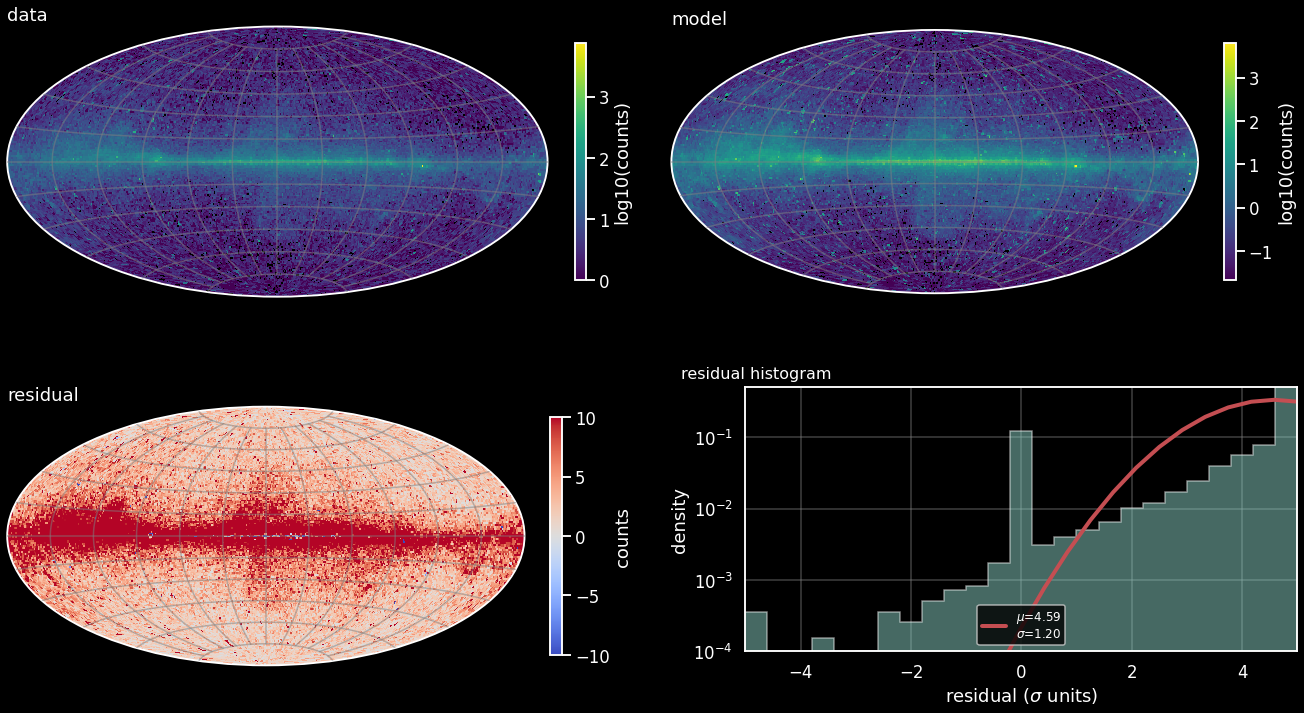

In [16]:
focus_band = pixel_table(3, 7)
show(f'## Detailed check for {focus_band}')

fig = plt.figure(figsize=(18, 10))
subfigs = fig.subfigures(2, 2, wspace=0.05, hspace=0.08)

focus_band.ait_plot('data', nside=64, fig=subfigs[0, 0], colorbar=True).title('data', x=0, ha='left')
focus_band.ait_plot('model', nside=64, fig=subfigs[0, 1], colorbar=True).title('model', x=0, ha='left')
focus_band.ait_plot('resid', nside=64, fig=subfigs[1, 0], colorbar=True, log=False, cmap='coolwarm', vmin=-10, vmax=10).title('residual', x=0, ha='left')
ResidualPlotter(focus_band, nside=64).residual_hist(ax=subfigs[1, 1].subplots(), legend_fontsize=12)
subfigs[1, 1].suptitle('residual histogram', x=0.02, ha='left', fontsize=16)
show(fig)

## Compare PSF2@4.22 GeV vs PSF3@7.50 GeV

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7ada3d64b610>
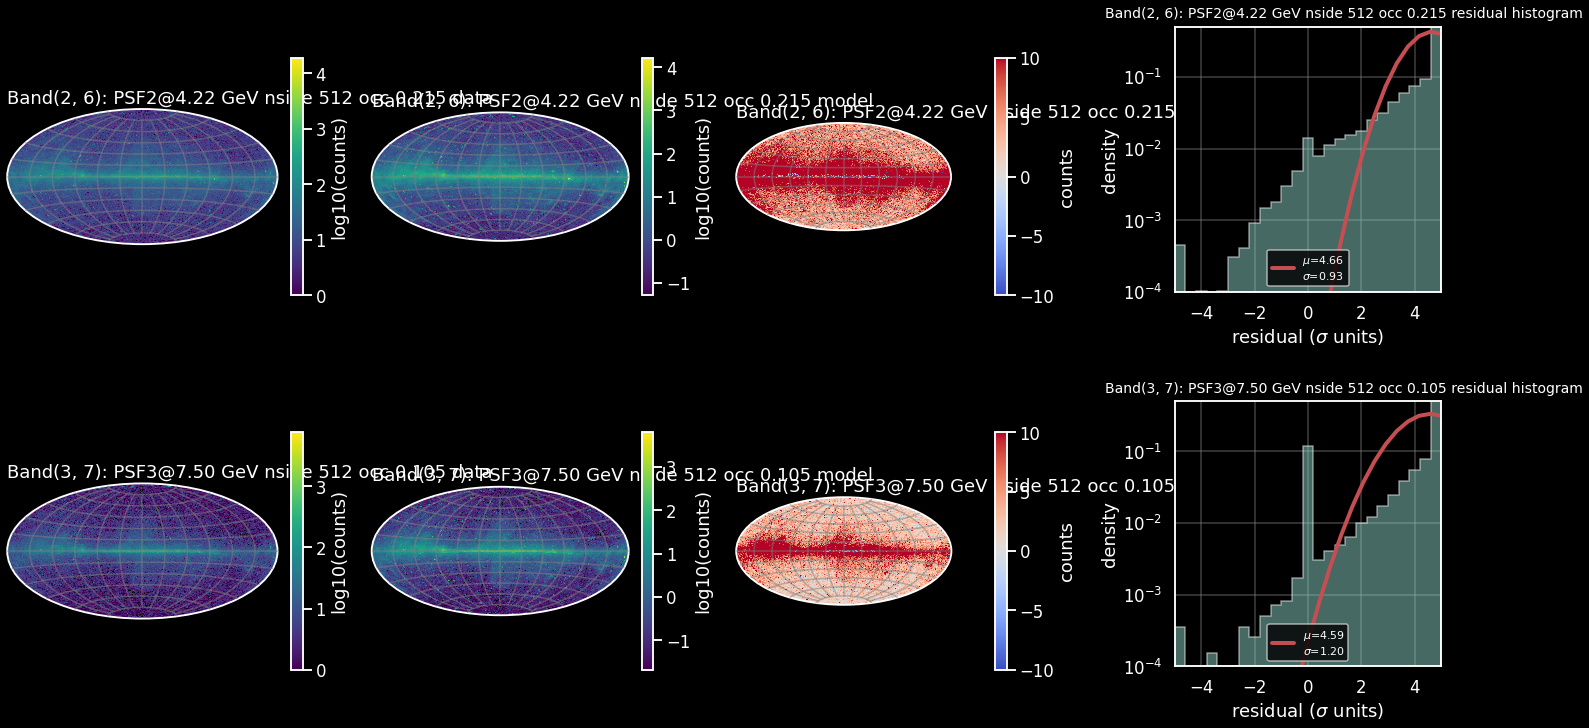

In [17]:
show('## Compare PSF2@4.22 GeV vs PSF3@7.50 GeV')

compare_bands = [pixel_table(2, 6), pixel_table(3, 7)]
fig = plt.figure(figsize=(20, 10))
subfigs = fig.subfigures(2, 4, wspace=0.05, hspace=0.08)

for row, b in enumerate(compare_bands):
    b.ait_plot('data', nside=64, fig=subfigs[row, 0], colorbar=True).title(f'{b} data', x=0, ha='left')
    b.ait_plot('model', nside=64, fig=subfigs[row, 1], colorbar=True).title(f'{b} model', x=0, ha='left')
    b.ait_plot('resid', nside=64, fig=subfigs[row, 2], colorbar=True, log=False, cmap='coolwarm', vmin=-10, vmax=10).title(f'{b} residual', x=0, ha='left')
    ResidualPlotter(b, nside=64).residual_hist(ax=subfigs[row, 3].subplots(), legend_fontsize=11)
    subfigs[row, 3].suptitle(f'{b} residual histogram', x=0.02, ha='left', fontsize=14)

show(fig)

In [18]:
show('## Ranked new-source candidates from unmatched residual clusters')

candidate_df = (
    cluster_match_df
    .query('matched_0p5deg == False')
    .copy()
    .assign(
        score=lambda d: (d['sigma'] * np.sqrt(d['npts'])) / np.log10(d['model'] + 10),
        low_model=lambda d: d['model'] < 100,
    )
    .sort_values(['score', 'sigma', 'npts', 'model'], ascending=[False, False, False, True])
    .reset_index(drop=True)
    [['cluster', 'glon', 'glat', 'sigma', 'npts', 'model', 'score', 'nearest_4fgl', 'sep_deg', 'low_model']]
)

show(candidate_df)

candidate_export_path = 'files/residual_new_source_candidates_uw1617.csv'
candidate_df.to_csv(candidate_export_path, index=False)
show(f'### Wrote ranked candidate table to {candidate_export_path}')

## Ranked new-source candidates from unmatched residual clusters

,cluster,glon,glat,sigma,npts,model,score,nearest_4fgl,sep_deg,low_model
0,19,-128.672,-15.249,38.6,3,17883.8,15.721100,FL16Y02889,0.728,False
1,12,-141.504,28.972,15.2,3,479.9,9.786662,None,NaN,False
2,14,-133.242,-15.249,22.9,3,11977.6,9.724581,None,NaN,False
3,21,24.961,-39.258,7.6,4,33.8,9.259969,None,NaN,True
4,7,-125.140,57.019,5.9,4,59.6,6.403962,None,NaN,True
5,10,84.799,52.995,5.0,2,3.5,6.255734,None,NaN,True
6,4,-161.016,28.972,10.7,3,988.1,6.179349,FL16Y03643,0.801,False
7,6,-78.047,-39.065,7.4,2,72.8,5.456212,FL16Y01679,0.916,True
8,11,39.727,0.448,11.4,2,2007.6,4.878317,FL16Y09794,0.593,False
9,2,-152.191,57.019,7.2,2,127.3,4.763287,None,NaN,False


### Wrote ranked candidate table to files/residual_new_source_candidates_uw1617.csv